In [1]:
from pathlib import Path

import imposter_utils as imposter_utils
import pandas as pd
from imposter_utils import ImposterGame
from IPython.display import Image, display
from IPython.utils import io

# Imposter game setup

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


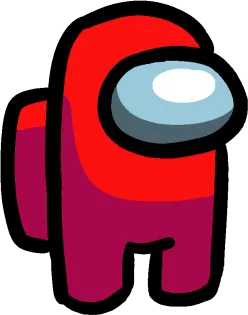

In [2]:
with io.capture_output():

    root = Path("/home/fred/Data/imposter_demo")
    ckpt_path = root / "epoch=91-step=14444.ckpt"
    schedule_encoder_path = root / "schedule_encoder.pkl"
    attributes_encoder_path = root / "attribute_encoder.pkl"

    real_schedules_path = root / "nts_schedules_2019_2023_200.csv"
    real_schedules = pd.read_csv(real_schedules_path)
    real_labels_path = root / "nts_attributes_2019_2023_200.csv"
    real_labels = pd.read_csv(real_labels_path)

    generator = imposter_utils.Generator(
        model_name="CVAEContLSTM",
        ckpt_path=ckpt_path,
        schedule_encoder_path=schedule_encoder_path,
        attributes_encoder_path=attributes_encoder_path,
    )

    imposter_game = ImposterGame(
        generator=generator,
        real_schedules=real_schedules,
        real_labels=real_labels,
        round_size=4,
    )

display(Image(filename="./assets/imposter.webp"))

# Play!

The imposter game shows you 4 activity schedules:
- 3 from the UK NTS (2019-2023)
- and one caveat synthetic activity schedule

Can you guess which one is synthetic?

You can rerun the following cells to keep playing.

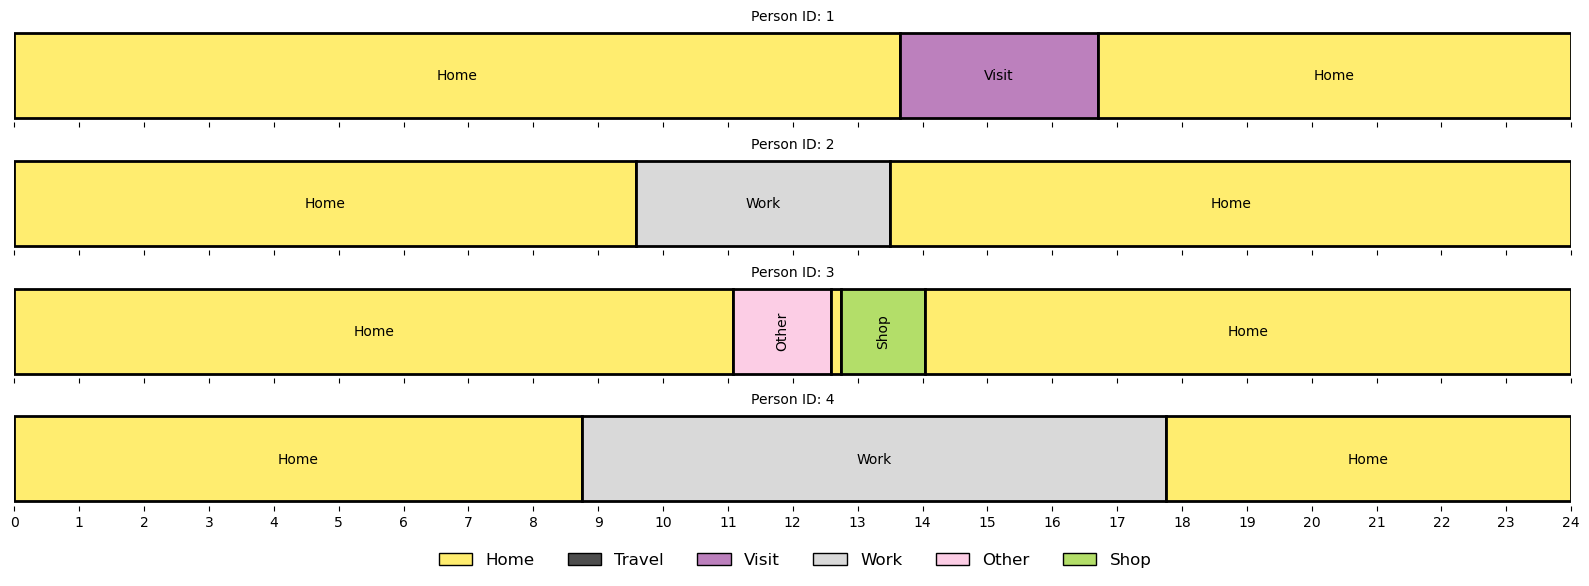

In [23]:
imposter = imposter_game.play()

In [24]:
imposter.guess(4)  # insert your guess here, e.g., 1, 2, 3, or 4

4 is wrong! Correct answer is: 1
Score: 15.38% over 13 rounds.
None
